Test

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df_1 = pd.read_excel('/Users/hendrikalbrecht/Dokumente/Z_Übungen/Mavenanalytics/Manufacturing Downtime/Manufacturing_Line_Productivity.xlsx', sheet_name='Line productivity')

In [4]:
df_2 = pd.read_excel('/Users/hendrikalbrecht/Dokumente/Z_Übungen/Mavenanalytics/Manufacturing Downtime/Manufacturing_Line_Productivity.xlsx', sheet_name='Products')
df_3 = pd.read_excel('/Users/hendrikalbrecht/Dokumente/Z_Übungen/Mavenanalytics/Manufacturing Downtime/Manufacturing_Line_Productivity.xlsx', sheet_name='Downtime factors')
df_4 = pd.read_excel('/Users/hendrikalbrecht/Dokumente/Z_Übungen/Mavenanalytics/Manufacturing Downtime/Manufacturing_Line_Productivity.xlsx', sheet_name='Line downtime')

In [5]:
df_1.head()

,Date,Product,Batch,Operator,Start Time,End Time
0,2024-08-29,OR-600,422111,Mac,11:50:00,14:05:00
1,2024-08-29,LE-600,422112,Mac,14:05:00,15:45:00
2,2024-08-29,LE-600,422113,Mac,15:45:00,17:35:00
3,2024-08-29,LE-600,422114,Mac,17:35:00,19:15:00
4,2024-08-29,LE-600,422115,Charlie,19:15:00,20:39:00


In [6]:
df_1.info()

<class 'pandas.DataFrame'>
RangeIndex: 38 entries, 0 to 37
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   Date        38 non-null     datetime64[us]
 1   Product     38 non-null     str           
 2   Batch       38 non-null     int64         
 3   Operator    38 non-null     str           
 4   Start Time  38 non-null     object        
 5   End Time    38 non-null     object        
dtypes: datetime64[us](1), int64(1), object(2), str(2)
memory usage: 1.9+ KB


In [7]:
df_1['Operator']

0         Mac
1         Mac
2         Mac
3         Mac
4     Charlie
5     Charlie
6     Charlie
7         Dee
8         Dee
9         Dee
10     Dennis
11     Dennis
12     Dennis
13     Dennis
14    Charlie
15    Charlie
16    Charlie
17    Charlie
18    Charlie
19        Dee
20        Dee
21        Dee
22        Dee
23        Mac
24        Mac
25        Mac
26        Dee
27        Dee
28        Dee
29        Dee
30     Dennis
31     Dennis
32     Dennis
33     Dennis
34    Charlie
35    Charlie
36    Charlie
37        Mac
Name: Operator, dtype: str

In [8]:
df_2.head()

,Product,Flavor,Size,Min batch time
0,OR-600,Orange,600 ml,60
1,LE-600,Lemon lime,600 ml,60
2,CO-600,Cola,600 ml,60
3,DC-600,Diet Cola,600 ml,60
4,RB-600,Root Beer,600 ml,60


In [9]:
df_2.info()

<class 'pandas.DataFrame'>
RangeIndex: 6 entries, 0 to 5
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   Product         6 non-null      str  
 1   Flavor          6 non-null      str  
 2   Size            6 non-null      str  
 3   Min batch time  6 non-null      int64
dtypes: int64(1), str(3)
memory usage: 324.0 bytes


In [10]:
df_3.head()

,Factor,Description,Operator Error
0,1,Emergency stop,No
1,2,Batch change,Yes
2,3,Labeling error,No
3,4,Inventory shortage,No
4,5,Product spill,Yes


In [11]:
df_3.info()

<class 'pandas.DataFrame'>
RangeIndex: 12 entries, 0 to 11
Data columns (total 3 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   Factor          12 non-null     int64
 1   Description     12 non-null     str  
 2   Operator Error  12 non-null     str  
dtypes: int64(1), str(2)
memory usage: 420.0 bytes


In [12]:
df_3['Operator Error']

0      No
1     Yes
2      No
3      No
4     Yes
5     Yes
6      No
7     Yes
8      No
9     Yes
10    Yes
11     No
Name: Operator Error, dtype: str

In [13]:
df_4.head()

,Unnamed: 0,Downtime factor,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,Unnamed: 10,Unnamed: 11,Unnamed: 12
0,Batch,1.0,2.0,3.0,4.0,5.0,6.0,7.0,8.0,9.0,10.0,11.0,12.0
1,422111,NaN,60.0,NaN,NaN,NaN,NaN,15.0,NaN,NaN,NaN,NaN,NaN
2,422112,NaN,20.0,NaN,NaN,NaN,NaN,NaN,20.0,NaN,NaN,NaN,NaN
3,422113,NaN,50.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,422114,NaN,NaN,NaN,25.0,NaN,15.0,NaN,NaN,NaN,NaN,NaN,NaN


In [14]:
# 1. Erste Zeile aus df_4 als neue Spaltennamen setzen
df_4_clean = df_4.copy()

df_4_clean.columns = df_4_clean.iloc[0]
df_4_clean = df_4_clean.iloc[1:].reset_index(drop=True)

# 2. Faktor-Mapping aus df_3 erstellen
factor_map = dict(zip(df_3["Factor"], df_3["Description"]))

# 3. Spaltennamen vorbereiten und umbenennen
new_columns = []

for col in df_4_clean.columns:
    # Batch-Spalte behalten
    if col == "Batch":
        new_columns.append("Batch")
    else:
        # aus 1.0 -> 1 machen
        factor_number = int(float(col))
        new_columns.append(factor_map[factor_number])

df_4_clean.columns = new_columns

# 4. Werte numerisch machen, außer Batch
for col in df_4_clean.columns:
    if col != "Batch":
        df_4_clean[col] = pd.to_numeric(df_4_clean[col], errors="coerce")

df_4_clean.head()

,Batch,Emergency stop,Batch change,Labeling error,Inventory shortage,Product spill,Machine adjustment,Machine failure,Batch coding error,Conveyor belt jam,Calibration error,Label switch,Other
0,422111,NaN,60.0,NaN,NaN,NaN,NaN,15.0,NaN,NaN,NaN,NaN,NaN
1,422112,NaN,20.0,NaN,NaN,NaN,NaN,NaN,20.0,NaN,NaN,NaN,NaN
2,422113,NaN,50.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,422114,NaN,NaN,NaN,25.0,NaN,15.0,NaN,NaN,NaN,NaN,NaN,NaN
4,422115,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,24.0,NaN,NaN


In [15]:
df_4_clean.isna().sum()

Batch                  0
Emergency stop        38
Batch change          33
Labeling error        36
Inventory shortage    29
Product spill         35
Machine adjustment    26
Machine failure       27
Batch coding error    32
Conveyor belt jam     37
Calibration error     35
Label switch          35
Other                 32
dtype: int64

In [16]:
# NaN Werte mit '0' füllen

df_4_clean = df_4_clean.fillna(0)
df_4_clean

,Batch,Emergency stop,Batch change,Labeling error,Inventory shortage,Product spill,Machine adjustment,Machine failure,Batch coding error,Conveyor belt jam,Calibration error,Label switch,Other
0,422111,0.0,60.0,0.0,0.0,0.0,0.0,15.0,0.0,0.0,0.0,0.0,0.0
1,422112,0.0,20.0,0.0,0.0,0.0,0.0,0.0,20.0,0.0,0.0,0.0,0.0
2,422113,0.0,50.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,422114,0.0,0.0,0.0,25.0,0.0,15.0,0.0,0.0,0.0,0.0,0.0,0.0
4,422115,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,24.0,0.0,0.0
5,422116,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
6,422117,0.0,10.0,0.0,0.0,0.0,5.0,0.0,0.0,0.0,0.0,0.0,0.0
7,422118,0.0,0.0,0.0,0.0,0.0,14.0,16.0,0.0,0.0,0.0,10.0,20.0
8,422119,0.0,0.0,0.0,25.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
9,422120,0.0,0.0,0.0,20.0,15.0,0.0,0.0,0.0,17.0,0.0,0.0,0.0


In [17]:
df_4_clean.isna().sum()

Batch                 0
Emergency stop        0
Batch change          0
Labeling error        0
Inventory shortage    0
Product spill         0
Machine adjustment    0
Machine failure       0
Batch coding error    0
Conveyor belt jam     0
Calibration error     0
Label switch          0
Other                 0
dtype: int64

In [18]:
# Berechnen total downtime per batch

df_4_clean["Total_Downtime"] = df_4_clean.drop(columns="Batch").sum(axis=1)

df_4_clean.head()

,Batch,Emergency stop,Batch change,Labeling error,Inventory shortage,Product spill,Machine adjustment,Machine failure,Batch coding error,Conveyor belt jam,Calibration error,Label switch,Other,Total_Downtime
0,422111,0.0,60.0,0.0,0.0,0.0,0.0,15.0,0.0,0.0,0.0,0.0,0.0,75.0
1,422112,0.0,20.0,0.0,0.0,0.0,0.0,0.0,20.0,0.0,0.0,0.0,0.0,40.0
2,422113,0.0,50.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,50.0
3,422114,0.0,0.0,0.0,25.0,0.0,15.0,0.0,0.0,0.0,0.0,0.0,0.0,40.0
4,422115,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,24.0,0.0,0.0,24.0


In [19]:
df_4_clean.info()

<class 'pandas.DataFrame'>
RangeIndex: 38 entries, 0 to 37
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Batch               38 non-null     object 
 1   Emergency stop      38 non-null     float64
 2   Batch change        38 non-null     float64
 3   Labeling error      38 non-null     float64
 4   Inventory shortage  38 non-null     float64
 5   Product spill       38 non-null     float64
 6   Machine adjustment  38 non-null     float64
 7   Machine failure     38 non-null     float64
 8   Batch coding error  38 non-null     float64
 9   Conveyor belt jam   38 non-null     float64
 10  Calibration error   38 non-null     float64
 11  Label switch        38 non-null     float64
 12  Other               38 non-null     float64
 13  Total_Downtime      38 non-null     float64
dtypes: float64(13), object(1)
memory usage: 4.3+ KB


Letzte Spalte von df_4_clean zu df_1 addieren/kopieren

In [20]:
df_1['Total_Downtime'] = df_4_clean['Total_Downtime']

In [21]:
df_1.columns

Index(['Date', 'Product', 'Batch', 'Operator', 'Start Time', 'End Time',
       'Total_Downtime'],
      dtype='str')

In [22]:
df_1.head()

,Date,Product,Batch,Operator,Start Time,End Time,Total_Downtime
0,2024-08-29,OR-600,422111,Mac,11:50:00,14:05:00,75.0
1,2024-08-29,LE-600,422112,Mac,14:05:00,15:45:00,40.0
2,2024-08-29,LE-600,422113,Mac,15:45:00,17:35:00,50.0
3,2024-08-29,LE-600,422114,Mac,17:35:00,19:15:00,40.0
4,2024-08-29,LE-600,422115,Charlie,19:15:00,20:39:00,24.0


#

1. Frage Line efficiency Groupby Product
3. Frage Leading factors -> df_4_clean spalten addieren, dann absteigend sortieren (grösstes zuerst)
2. Frage operators underperforming (nach operators gruppieren (mac, charlie), avg downtime, vergleichen mit avg., dann gucken wer unter und wer über avg. liegt
4. Frage Do operators struggle with particular operator error | operator error J/N (df_3) | df_4 zwei neue spalten J oder N, füllen mit der jeweiligen downtime | zuordnen wieviel zeit operator downtime bzw. maschinelle downtime | df_1 breakdown 75 minuten total downtime (anteil maschinell, anteil human) | per operator gruppieren (mac 100 minuten human, 10 minuten maschinell)
5. Natalia macht Frage 1 + 3, Hendrik macht 2 + 4


In [24]:
"""
Question #4
Do any operators struggle with a particular operator error?
Possible KPIs
 - which error with which operator
 - how much time per operator
"""

'\nQuestion #4\nDo any operators struggle with a particular operator error?\nPossible KPIs\n - which error with which operator\n - how much time per operator\n'

df_1 = Haupttabelle
df_3 = Ursachen-Lexikon
df_4_clean = Downtime Details

Total_Downtime = Dauer
Downtime_Count = Häufigkeit

In [35]:
# Create a list of downtime factors, classified as operator errors
# Filter df_3 where 'Operator error' = Yes
# Select the corresponding values from the Description column
# Convert the result into a Python list

operator_errors = df_3[df_3['Operator Error'] == 'Yes']['Description'].tolist()
operator_errors

['Batch change',
 'Product spill',
 'Machine adjustment',
 'Batch coding error',
 'Calibration error',
 'Label switch']

In [36]:
# Use existing operator error list
# Select Batch column + operator error columns from df_4_clean
# Create a new dataframe with only relevant operator-related errors

error_df = df_4_clean[
    ["Batch"] + operator_errors
]

error_df.head()

,Batch,Batch change,Product spill,Machine adjustment,Batch coding error,Calibration error,Label switch
0,422111,60.0,0.0,0.0,0.0,0.0,0.0
1,422112,20.0,0.0,0.0,20.0,0.0,0.0
2,422113,50.0,0.0,0.0,0.0,0.0,0.0
3,422114,0.0,0.0,15.0,0.0,0.0,0.0
4,422115,0.0,0.0,0.0,0.0,24.0,0.0


In [ ]:
# Add the Operator column from df_1 to error_df

error_df["Operator"] = df_1["Operator"]
error_df.head()

,Batch,Batch change,Product spill,Machine adjustment,Batch coding error,Calibration error,Label switch,Operator
0,422111,60.0,0.0,0.0,0.0,0.0,0.0,Mac
1,422112,20.0,0.0,0.0,20.0,0.0,0.0,Mac
2,422113,50.0,0.0,0.0,0.0,0.0,0.0,Mac
3,422114,0.0,0.0,15.0,0.0,0.0,0.0,Mac
4,422115,0.0,0.0,0.0,0.0,24.0,0.0,Charlie


In [ ]:
# Create summary table of operator-related errors
# Group by operator
# Sum downtime minutes for each operator error type

operator_error_summary = error_df.groupby("Operator")[
    operator_errors
].sum()

operator_error_summary

,Batch change,Product spill,Machine adjustment,Batch coding error,Calibration error,Label switch
Operator,,,,,,
Charlie,10.0,22.0,118.0,44.0,24.0,10.0
Dee,20.0,15.0,79.0,30.0,25.0,23.0
Dennis,0.0,20.0,120.0,24.0,0.0,0.0
Mac,130.0,0.0,15.0,47.0,0.0,0.0


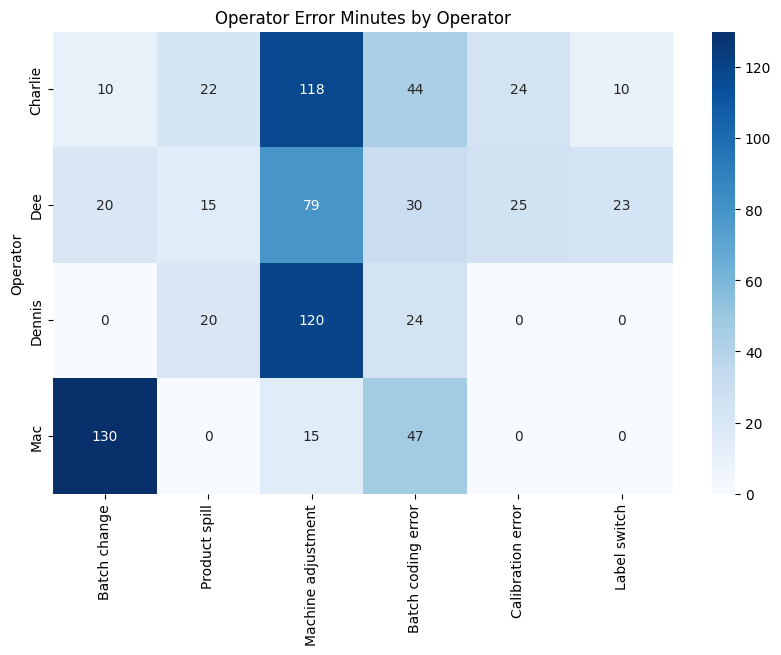

In [40]:
plt.figure(figsize=(10,6))

sns.heatmap(
    operator_error_summary,
    annot=True,
    cmap="Blues",
    fmt=".0f"
)

plt.title("Operator Error Minutes by Operator")
plt.show()

Overall findings:

To evaluate whether certain operators struggle with specific operator-related errors, downtime minutes were grouped by operator and error type.

The results show clear differences in error patterns across operators. Mac recorded the highest downtime from Batch Change issues (130 minutes), indicating difficulties during changeover processes.

Dennis and Charlie both showed high downtime related to Machine Adjustment (120 and 118 minutes), suggesting challenges with machine setup or calibration tasks.

Dee did not show one dominant issue, but instead displayed a more balanced spread of moderate errors across several categories.

Overall, the analysis suggests that operators tend to struggle with different types of errors rather than sharing the same weaknesses. This indicates that targeted training or process improvements may be more effective than a general approach.

Overall finding short:

Operator error patterns differ noticeably across employees. Mac had the highest downtime from Batch Change issues, while Dennis and Charlie recorded the most downtime from Machine Adjustment. Dee showed smaller issues across multiple categories. This suggests that operator-specific training may help reduce downtime more effectively than a general solution.

In [ ]:
# Operator related downtime

operator_error_summary.sum(axis=1)

Operator
Charlie    228.0
Dee        192.0
Dennis     164.0
Mac        192.0
dtype: float64

In [ ]:
# Total downtime

df_1.groupby("Operator")["Total_Downtime"].sum()

Operator
Charlie    384.0
Dee        370.0
Dennis     302.0
Mac        332.0
Name: Total_Downtime, dtype: float64

In [45]:
# Operator error share (%)

operator_error_share = (
    operator_error_summary.sum(axis=1)
    / df_1.groupby("Operator")["Total_Downtime"].sum()
) * 100

operator_error_share.round(1)

Operator
Charlie    59.4
Dee        51.9
Dennis     54.3
Mac        57.8
dtype: float64

<Axes: xlabel='Operator'>

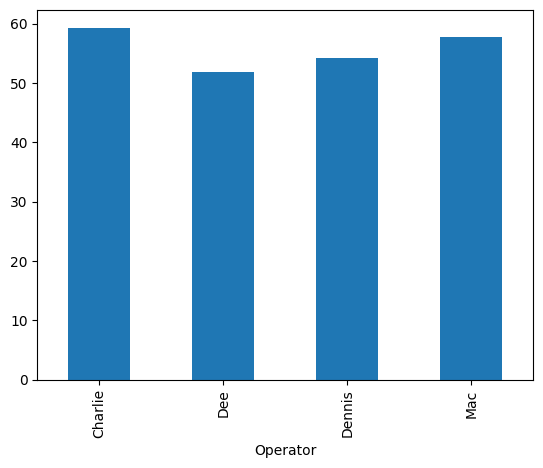

In [44]:
operator_error_share.plot(kind="bar")